In [5]:
import sys
sys.path.insert(0, "/home/nakmi/Project/personal/langchain-agent-dev-tuto")

In [6]:
from src.dps.deep_research.tools_zh import think_tool, tavily_search
tools = [tavily_search, think_tool]

In [8]:
from datetime import datetime
from src.utils import show_prompt, format_messages
from src.dps.deep_research.prompts_zh import (
    RESEARCHER_INSTRUCTIONS,
    RESEARCH_WORKFLOW_INSTRUCTIONS,
    SUBAGENT_DELEGATION_INSTRUCTIONS,
)

In [9]:
show_prompt(RESEARCHER_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  你是一名研究助理，正在对用户输入的主题进行调研。作为参考，今天的日期是 {date}。                                │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  你的工作是使用工具收集与用户输入主题相关的信息。                                                               │
│  你可以使用提供给你的任何研究工具来寻找有助于回答研究问题的资源。                                               │
│  你可以串行或并行地调用这些工具，你的研究在一个工具调用循环中进行。                                             │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Research Tools>                                                                                     │
│  你可以使用两个特定的研究工具：                                                                                 │
│  1. **tavily_search**：用于进行网络搜索以收集信息                                                               │
│  2. **think_tool**：用于在研究过程中进行反思和策略规划                                                          │
│  **关键要求：每次搜索后都必须使用 think_tool 反思结果并规划下一步**                                             │
│  </Available Research Tools>                                                                                    │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  像一个时间有限的人类研究员一样思考。遵循以下步骤：                                                             │
│                                                                                                                 │
│  1. **仔细阅读问题** — 用户具体需要什么信息？                                                                   │
│  2. **从宽泛搜索开始** — 先使用宽泛、综合性的查询                                                               │
│  3. **每次搜索后暂停评估** — 我已经有足够的信息来回答了吗？还缺什么？                                           │
│  4. **逐步缩小搜索范围** — 填补信息空白                                                                         │
│  5. **能自信回答时立即停止** — 不要为了追求完美而持续搜索                                                       │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **工具调用预算**（防止过度搜索）：                                                                             │
│  - **简单查询**：最多使用 2-3 次搜索工具调用                                                                    │
│  - **复杂查询**：最多使用 5 次搜索工具调用                                                                      │
│  - **强制停止**：如果 5 次搜索后仍未找到合适的来源，必须停止                                                    │
│                                                                                                                 │
│  **遇到以下情况时立即停止**：                                                                                   │
│  - 你已经能够全面回答用户的问题                                                                                 │
│  - 你已有 3 个以上相关的示例/来源                                                                               │
│  - 最近 2 次搜索返回了相似的信息                                                                                │
│  </Hard Limits>                                                                                                 │
│                                       

In [10]:
# Get current date
current_date = datetime.now().strftime("%Y-%m-%d")

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "system_prompt": RESEARCHER_INSTRUCTIONS.format(date=current_date),
    "tools": [tavily_search, think_tool],
}

In [11]:
# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Combine orchestrator instructions (RESEARCHER_INSTRUCTIONS only for sub-agents)
INSTRUCTIONS = (
    RESEARCH_WORKFLOW_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    +  SUBAGENT_DELEGATION_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
    )
)

show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # 研究工作流                                                                                                   │
│                                                                                                                 │
│  所有研究请求都必须遵循以下工作流：                                                                             │
│                                                                                                                 │
│  1. **规划**：使用 write_todos 创建待办列表，将研究任务拆分为聚焦的子任务                                       │
│  2. **保存请求**：使用 write_file() 将用户的研究问题保存至 `/research_request.md`                               │
│  3. **研究**：使用 task() 工具将研究任务委派给子 Agent——务必使用子 Agent 进行研究，切勿自行执行研究             │
│  4. **综合**：审阅所有子 Agent 的研究发现，合并引用源（每个唯一 URL 在所有发现中只分配一个编号）                │
│  5. **撰写报告**：将完整的最终报告写入 `/final_report.md`（参见下方报告撰写指南）                               │
│  6. **验证**：读取 `/research_request.md`，确认你已覆盖所有方面，且引用和结构正确                               │
│                                                                                                                 │
│  ## 研究规划指南                                                                                                │
│  - 将相似的研究任务合并为一个 TODO，以减少开销                                                                  │
│  - 对于简单的事实查询，使用 1 个子 Agent                                                                        │
│  - 对于比较类或多维度话题，委派给多个并行的子 Agent                                                             │
│  - 每个子 Agent 应研究一个特定方面并返回研究发现                                                                │
│                                                                                                                 │
│  ## 报告撰写指南                                                                                                │
│                                                                                                                 │
│  将最终报告写入 `/final_report.md` 时，请遵循以下结构模板：                                                     │
│                                                                                                                 │
│  **比较类：**                                                                                                   │
│  1. 引言                                                                                                        │
│  2. 主题 A 概述                                                                                                 │
│  3. 主题 B 概述                                                                                                 │
│  4. 详细对比                                                                                                    │
│  5. 结论                                                                                                        │
│                                                                                                                 │
│  **列表/排名类：**                                                                                              │
│  直接列出条目及详情——无需引言：                                                                                 │
│  1. 条目 1 及说明                                                                                               │
│  2. 条目 2 及说明                                                                                               │
│  3. 条目 3 及说明                                                                                               │
│                                                                                                                 │
│  **总结/概述类：**                                                                                              │
│  1. 主题概述                                                     

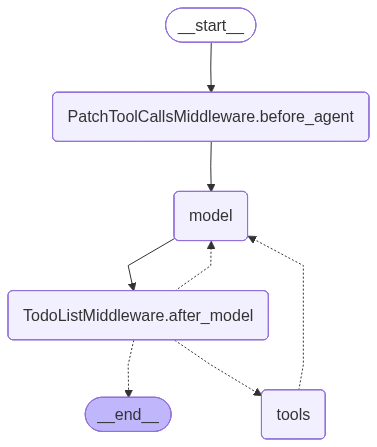

In [13]:
from IPython.display import Image, display
from deepagents import create_deep_agent
from dotenv import load_dotenv
import os
from langchain_qwq import ChatQwen

load_dotenv()

api_key = os.getenv("DASHSCOPE_API_KEY")
if not api_key:
    raise ValueError("Please set DASHSCOPE_API_KEY before running this script.")

model = ChatQwen(
    base_url=os.getenv("DASHSCOPE_API_BASE"),
    model="qwen3-max",
    enable_thinking=True,
    temperature=0.3,
    api_key=api_key,
)

agent = create_deep_agent(
    model=model,
    system_prompt=INSTRUCTIONS,
    tools=tools,
    subagents=[research_sub_agent],
)
display(Image(agent.get_graph().draw_mermaid_png()))

In [14]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "说说提示词工程的经验",
            }
        ],
    }, 
)
format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ 说说提示词工程的经验                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "\u4fdd\u5b58\u7814\u7a76\u8bf7\u6c42",                                                        │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "\u59d4\u6d3e\u7814\u7a76\u4efb\u52a1\u7ed9\u5b50Agent -                                       │
│ \u63d0\u793a\u8bcd\u5de5\u7a0b\u7ecf\u9a8c",                                                                    │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "\u7efc\u5408\u7814\u7a76\u53d1\u73b0\u5e76\u64b0\u5199\u62a5\u544a",                          │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_82e64908f9324b05a4154dfd                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': '保存研究请求', 'status': 'in_progress'}, {'content': '委派研究任务给子Agent  │
│ - 提示词工程经验', 'status': 'pending'}, {'content': '综合研究发现并撰写报告', 'status': 'pending'}]            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "content":                                                                                                    │
│ "\u7814\u7a76\u95ee\u9898\uff1a\u8bf4\u8bf4\u63d0\u793a\u8bcd\u5de5\u7a0b\u7684\u7ecf\u9a8c\n\n\u9700\u8981\u78 │
│ 14\u7a76\u7684\u5185\u5bb9\uff1a\n-                                                                             │
│ \u63d0\u793a\u8bcd\u5de5\u7a0b\u7684\u6838\u5fc3\u539f\u5219\u548c\u6700\u4f73\u5b9e\u8df5\n-                   │
│ \u5e38\u7528\u7684\u63d0\u793a\u8bcd\u5de5\u7a0b\u6280\u672f\uff08\u5982\u601d\u7ef4\u94fe\u3001\u5c11\u6837\u6 │
│ 72c\u5b66\u4e60\u7b49\uff09\n-                                                                                  │
│ \u63d0\u793a\u8bcd\u8bbe\u8ba1\u7684\u5e38\u89c1\u6a21\u5f0f\u548c\u6a21\u677f\n-                               │
│ \u907f\u514d\u7684\u5e38\u89c1\u9677\u9631\u548c\u9519\u8bef\n-                                                 │
│ \u4e0d\u540c\u573a\u666f\u4e0b\u7684\u63d0\u793a\u8bcd\u4f18\u5316\u7b56\u7565\n-                               │
│ \u5b9e\u9645\u6848\u4f8b\u548c\u7ecf\u9a8c\u5206\u4eab",                                                        │
│   "file_path": "/research_request.md"                                                                           │
│ }                                                                                                               │
│    ID: call_8a5d7a7a79a74617b3a6fed7                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file /research_request.md                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "\u4fdd\u5b58\u7814\u7a76\u8bf7\u6c42",                                                        │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "\u59d4\u6d3e\u7814\u7a76\u4efb\u52a1\u7ed9\u5b50Agent -                                       │
│ \u63d0\u793a\u8bcd\u5de5\u7a0b\u7ecf\u9a8c",                                                                    │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "\u7efc\u5408\u7814\u7a76\u53d1\u73b0\u5e76\u64b0\u5199\u62a5\u544a",                          │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_483592ba4da340aea7377ea6                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': '保存研究请求', 'status': 'completed'}, {'content': '委派研究任务给子Agent -  │
│ 提示词工程经验', 'status': 'completed'}, {'content': '综合研究发现并撰写报告', 'status': 'completed'}]          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: read_file                                                                                         │
│    Args: {                                                                                                      │
│   "file_path": "/research_request.md"                                                                           │
│ }                                                                                                               │
│    ID: call_bdb5e97a54c84c7aae1ac91d                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│      1  研究问题：说说提示词工程的经验                                                                          │
│      2                                                                                                          │
│      3  需要研究的内容：                                                                                        │
│      4  - 提示词工程的核心原则和最佳实践                                                                        │
│      5  - 常用的提示词工程技术（如思维链、少样本学习等）                                                        │
│      6  - 提示词设计的常见模式和模板                                                                            │
│      7  - 避免的常见陷阱和错误                                                                                  │
│      8  - 不同场景下的提示词优化策略                                                                            │
│      9  - 实际案例和经验分享                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 我已完成对提示词工程经验的全面研究。以下是核心要点总结：                                                        │
│                                                                                                                 │
│ ## 🎯 核心原则                                                                                                  │
│                                                                                                                 │
│ 1. **清晰具体性**：避免模糊，提供详细指令                                                                       │
│ 2. **正向指令**：使用"请简洁"而非"不要冗长"                                                                     │
│ 3. **结构化框架**：角色-任务-格式（RTF）或CRISPE框架                                                            │
│                                                                                                                 │
│ ## 🔧 关键技术                                                                                                  │
│                                                                                                                 │
│ - **思维链（CoT）**：展示推理过程，提升复杂任务表现                                                             │
│ - **少样本学习**：提供1-3个示例引导模型                                                                         │
│ - **树状思维（ToT）**：探索多路径，选择最优解                                                                   │
│ - **反思提示**：让模型自我审查改进                                                                              │
│ - **分步提示**：分解复杂任务                                                                                    │
│                                                                                                                 │
│ ## ⚠️ 常见陷阱                                                                                                  │
│                                                                                                                 │
│ - 模糊提示导致不一致输出                                                                                        │
│ - 过度复杂的单一提示                                                                                            │
│ - 上下文管理不当（"lost in the middle"效应）                                                                    │
│ - 忽视偏见和安全问题                                                                                            │
│                                                                                                                 │
│ ## 📊 优化方法                                                                                                  │
│                                                                                                                 │
│ - **迭代优化**：从简单开始，逐步改进                                                                            │
│ - **A/B测试**：使用量化指标评估                                                                                 │
│ - **模板化**：创建可复用提示模板                                                                                │
│                                                                                                                 │
│ 完整详细报告（含学术引用、实际案例、工具推荐）已保存至                                                          │
│ `/final_report.md`，涵盖7大原则、9种技术、评估指标和学习资源。                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯